# Breast Cancer 5-Year Survival — GridSearch Hyperparameter Optimisation



In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    classification_report, matthews_corrcoef,
)
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
HOLDOUT_COHORTS = {4.0, 5.0}

## 1. Load pre-imputed data and build the 5-year survival label


In [2]:
df = pd.read_csv('../data/Final_metabric_data_mice_imputed.tsv', sep='\t')

print(f'Raw data shape: {df.shape}')

died_early  = (df['Overall Survival Status'] == '1:DECEASED') & (df['Overall Survival (Months)'] < 60)
survived_5y = df['Overall Survival (Months)'] >= 60
censored    = (df['Overall Survival Status'] == '0:LIVING')  & (df['Overall Survival (Months)'] < 60)

df['label'] = np.nan
df.loc[died_early,  'label'] = 0
df.loc[survived_5y, 'label'] = 1
df = df[~censored].reset_index(drop=True)

print(f'Rows after excluding censored: {len(df)}')
print(df['label'].value_counts().rename({0: 'died <5yr', 1: 'survived 5yr'}))

Raw data shape: (1981, 30)
Rows after excluding censored: 1917
label
survived 5yr    1490
died <5yr        427
Name: count, dtype: int64


## 2. Select features — no imputation needed

In [3]:
NUMERIC = [
    'Age at Diagnosis',
    'Nottingham prognostic index',
    'gain',
    'hetloss',
    'Tumor Size',
    'amp',
    'TMB (nonsynonymous)',
    'homdel',
]

CATEGORICAL = [
    'Type of Breast Surgery',
    'Primary Tumor Laterality',
    'Pam50 + Claudin-low subtype',
    'Cellularity',
]

FEATURES = NUMERIC + CATEGORICAL

df = df[FEATURES + ['Cohort', 'label']].dropna(subset=['Cohort', 'label']).reset_index(drop=True)

print(f'Rows: {len(df)}')
print('Missing values per feature column (should all be 0):')
print(df[FEATURES].isna().sum().to_string())
print(f'\nLabel distribution: {df["label"].value_counts().to_dict()}')
print(f'Cohorts present: {sorted(df["Cohort"].unique())}')

X      = df[FEATURES]
y      = df['label'].astype(int)
groups = df['Cohort']

Rows: 1917
Missing values per feature column (should all be 0):
Age at Diagnosis               0
Nottingham prognostic index    0
gain                           0
hetloss                        0
Tumor Size                     0
amp                            0
TMB (nonsynonymous)            0
homdel                         0
Type of Breast Surgery         0
Primary Tumor Laterality       0
Pam50 + Claudin-low subtype    0
Cellularity                    0

Label distribution: {1.0: 1490, 0.0: 427}
Cohorts present: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


## 3. Split: seal cohorts {4, 5} as final holdout

In [4]:
holdout_mask = groups.isin(HOLDOUT_COHORTS)

X_dev,  y_dev,  groups_dev = (X[~holdout_mask].reset_index(drop=True),
                               y[~holdout_mask].reset_index(drop=True),
                               groups[~holdout_mask].reset_index(drop=True))
X_hold, y_hold             = (X[holdout_mask].reset_index(drop=True),
                               y[holdout_mask].reset_index(drop=True))

print(f'Dev pool : {len(X_dev)} rows, cohorts {sorted(groups_dev.unique())}')
print(f'Holdout  : {len(X_hold)} rows, cohorts {sorted(groups[holdout_mask].unique())} — sealed until Section 6')

Dev pool : 1518 rows, cohorts [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
Holdout  : 399 rows, cohorts [np.float64(4.0), np.float64(5.0)] — sealed until Section 6


## 4. Base pipelines and parameter grids


In [5]:
def make_preprocessor(scale_numeric=True):
    num_pipe = Pipeline([('scaler', StandardScaler())]) if scale_numeric else 'passthrough'
    cat_pipe = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer([
        ('num', num_pipe, NUMERIC),
        ('cat', cat_pipe, CATEGORICAL),
    ])

spw = (y_dev == 0).sum() / (y_dev == 1).sum()

BASE_PIPES = {
    'logistic_regression': Pipeline([
        ('prep',  make_preprocessor(scale_numeric=True)),
        # saga solver supports both l1 and l2 penalties
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced',
                                     solver='saga', random_state=RANDOM_STATE)),
    ]),
    'lightgbm': Pipeline([
        ('prep',  make_preprocessor(scale_numeric=False)),
        ('model', LGBMClassifier(scale_pos_weight=spw, random_state=RANDOM_STATE, verbosity=-1)),
    ]),
}

PARAM_GRIDS = {
    'logistic_regression': {
        'model__C':       [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
    },
    'lightgbm': {
        'model__n_estimators':  [100, 300],
        'model__max_depth':     [3, 5, 7],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves':    [31, 63],
    },
}

## 5. GridSearchCV — leave-one-cohort-out on the dev pool (cohorts 1, 2, 3)



In [6]:
gkf = GroupKFold(n_splits=groups_dev.nunique())  # 3 folds

gs_objects      = {}
best_estimators = {}

for model_name, pipe in BASE_PIPES.items():
    print(f'\nRunning GridSearchCV for {model_name}...')
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=PARAM_GRIDS[model_name],
        cv=gkf,
        scoring='roc_auc',
        refit=True,         # refit best params on entire dev pool
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(X_dev, y_dev, groups=groups_dev)

    gs_objects[model_name]      = gs
    best_estimators[model_name] = gs.best_estimator_

    print(f'  Best params     : {gs.best_params_}')
    print(f'  Best CV ROC-AUC : {gs.best_score_:.4f}')


Running GridSearchCV for logistic_regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  Best params     : {'model__C': 0.1, 'model__penalty': 'l2'}
  Best CV ROC-AUC : 0.7395

Running GridSearchCV for lightgbm...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
  Best params     : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__num_leaves': 31}
  Best CV ROC-AUC : 0.7391


## 6. Full CV results table



In [7]:
for model_name, gs in gs_objects.items():
    results   = pd.DataFrame(gs.cv_results_)
    param_cols = [c for c in results.columns if c.startswith('param_')]
    display_cols = param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']
    top5 = (results[display_cols]
            .sort_values('rank_test_score')
            .head(5)
            .reset_index(drop=True))
    top5.columns = [c.replace('param_model__', '') for c in top5.columns]
    print(f'\n=== {model_name} — top 5 by CV ROC-AUC ===')
    print(top5.round(4).to_string(index=False))


=== logistic_regression — top 5 by CV ROC-AUC ===
    C penalty  mean_test_score  std_test_score  rank_test_score
  0.1      l2           0.7395          0.0316                1
100.0      l1           0.7388          0.0302                2
100.0      l2           0.7387          0.0301                3
 10.0      l1           0.7386          0.0302                4
 10.0      l2           0.7386          0.0302                5

=== lightgbm — top 5 by CV ROC-AUC ===
 learning_rate  max_depth  n_estimators  num_leaves  mean_test_score  std_test_score  rank_test_score
          0.05          3           100          31           0.7391          0.0340                1
          0.05          3           100          63           0.7391          0.0340                1
          0.05          5           100          63           0.7328          0.0304                3
          0.05          5           100          31           0.7328          0.0304                3
          0.10 

## 7. Final evaluation on the holdout (cohorts 4, 5)

In [8]:
for model_name, pipe in best_estimators.items():
    proba = pipe.predict_proba(X_hold)[:, 1]
    preds = pipe.predict(X_hold)

    print(f'\n=== {model_name} — holdout (cohorts 4, 5) ===')
    print(f'  Best params : {gs_objects[model_name].best_params_}')
    print(f'  ROC-AUC : {roc_auc_score(y_hold, proba):.3f}')
    print(f'  PR-AUC  : {average_precision_score(y_hold, proba):.3f}')
    print(f'  MCC     : {matthews_corrcoef(y_hold, preds):.3f}')
    print(classification_report(y_hold, preds, target_names=['died_<5y', 'survived_5y']))


=== logistic_regression — holdout (cohorts 4, 5) ===
  Best params : {'model__C': 0.1, 'model__penalty': 'l2'}
  ROC-AUC : 0.756
  PR-AUC  : 0.893
  MCC     : 0.340
              precision    recall  f1-score   support

    died_<5y       0.39      0.78      0.52        94
 survived_5y       0.90      0.62      0.74       305

    accuracy                           0.66       399
   macro avg       0.64      0.70      0.63       399
weighted avg       0.78      0.66      0.68       399


=== lightgbm — holdout (cohorts 4, 5) ===
  Best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__num_leaves': 31}
  ROC-AUC : 0.761
  PR-AUC  : 0.908
  MCC     : 0.358
              precision    recall  f1-score   support

    died_<5y       0.41      0.74      0.53        94
 survived_5y       0.90      0.67      0.77       305

    accuracy                           0.69       399
   macro avg       0.65      0.71      0.65       399
weighted avg   

## 8. ROC and PR curves — holdout (cohorts 4, 5)

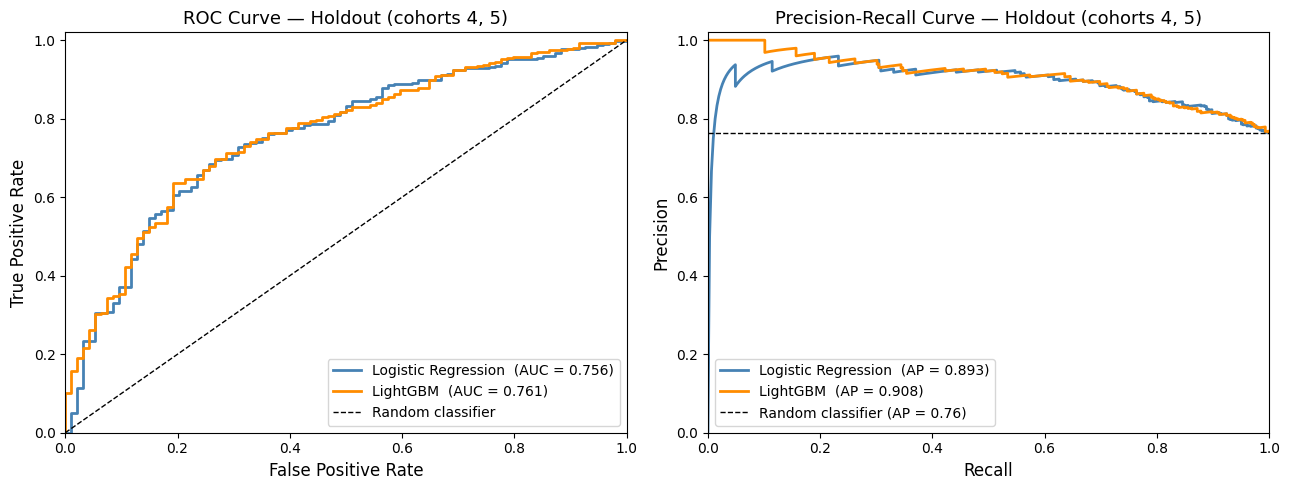

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

colors = {'logistic_regression': 'steelblue', 'lightgbm': 'darkorange'}
labels_map = {'logistic_regression': 'Logistic Regression', 'lightgbm': 'LightGBM'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC ---
ax = axes[0]
for model_name, pipe in best_estimators.items():
    proba = pipe.predict_proba(X_hold)[:, 1]
    fpr, tpr, _ = roc_curve(y_hold, proba)
    auc = roc_auc_score(y_hold, proba)
    ax.plot(fpr, tpr, color=colors[model_name], lw=2,
            label=f'{labels_map[model_name]}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Holdout (cohorts 4, 5)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# --- PR ---
ax = axes[1]
baseline = y_hold.mean()
for model_name, pipe in best_estimators.items():
    proba = pipe.predict_proba(X_hold)[:, 1]
    prec, rec, _ = precision_recall_curve(y_hold, proba)
    auc = average_precision_score(y_hold, proba)
    ax.plot(rec, prec, color=colors[model_name], lw=2,
            label=f'{labels_map[model_name]}  (AP = {auc:.3f})')

ax.axhline(baseline, color='k', lw=1, linestyle='--',
           label=f'Random classifier (AP = {baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Holdout (cohorts 4, 5)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()